<a href="https://colab.research.google.com/github/tatsuki75/T.Yajima.github.io/blob/main/%E3%83%9D%E3%83%BC%E3%83%88%E3%83%95%E3%82%A9%E3%83%AA%E3%82%AA_20260403.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
from google.colab import drive
drive.mount('/content/drive')

# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
# Excelbook1データの呼び込み
df_products= pd.read_excel("/content/drive/MyDrive/Aidemy  成果物/Book1-4.xlsx", skiprows=1)

# Excelbook2データの呼び込み
df_raw_materials= pd.read_excel("/content/drive/MyDrive/Aidemy  成果物/Book2-3.xlsx", skiprows=1 )

#全配列数の確認
print(df_products.shape)
print(df_raw_materials.shape)

(70, 43)
(37, 11)


In [61]:
df_products

,Unnamed: 0,Code,Mw,M-1002,M-1004,M-1016,M-1022,M-1029,M-1032,M-1020,...,A-3293,A-3295,A-174,FM0721,KBM503,HD F-225P,A-3250,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,NaN,HR-1,8400.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0
1,NaN,HR-2,5500.0,25.0,12.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0
2,NaN,HR-3,28000.0,5.0,65.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0
3,NaN,HR-4,6000.0,20.0,10.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.7,NaN,NaN,100.0
4,NaN,LR-5,43000.0,5.0,20.0,10.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,NaN,LR-52,130000.0,NaN,55.0,24.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0
66,NaN,LR-53,90000.0,5.0,86.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0
67,NaN,LR-54,37000.0,10.0,30.0,28.5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0
68,NaN,HR-55,31000.0,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0


In [62]:
#重複データを削除する
df_products1= df_products.drop_duplicates()

#df_products1の特徴量データをX1に、ラベルデータをy1に格納
#df_raw_materialsの2列目はラベルデータ、3列目以降は特徴量データ
X1,y1 = df_products1.iloc[0:,3:40], df_products1.iloc[0:,1]

#df_raw_materialsの特徴量データをX2に、ラベルデータをy2に格納
#df_raw_materialsの2列目はラベルデータ、3列目以降は特徴量データ
X2,y2 = df_raw_materials.iloc[0:,2:19], df_raw_materials.iloc[0:,1]


#ブランクは全て0
# fillnaで欠損値を補完する
X1 = X1.fillna(0)

#ブランクは全て0
# fillnaで欠損値を補完する
X2 = X2.fillna(0)

In [63]:
#製品データの特徴量データのX1の確認
X1

,M-1002,M-1004,M-1016,M-1022,M-1029,M-1032,M-1020,M-1079,M-1027,M-1013,...,M-1037,M-1038,A-3337,A-3293,A-3295,A-174,FM0721,KBM503,HD F-225P,A-3250
0,35.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,25.0,12.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.0,65.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20.0,10.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.7
4,5.0,20.00,10.0,0.0,0.0,0.0,0.0,0.0,0.0,49.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,67.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,45.0,18.00,0.0,16.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,25.0,20.00,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,35.0,27.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,59.4,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:
#原料の特徴量のデータ
X2.shape

(37, 9)

In [65]:
X2[["Fw", "Tg","SP", "A.V.", "Amine Value"]].head()

,Fw,Tg,SP,A.V.,Amine Value
0,104.0,382.0,19.52,0.0,0.0
1,100.0,355.0,17.68,0.0,0.0
2,142.0,295.0,17.07,0.0,0.0
3,142.0,325.0,16.77,0.0,0.0
4,142.0,353.0,16.14,0.0,0.0


In [66]:
#原料の特徴量データのダミー係数(Methacrylate,Acrylate,others以外)を正規化
from sklearn import preprocessing
ins = preprocessing.MinMaxScaler()

X2[["Fw", "Tg","SP", "A.V.", "Amine Value"]] = ins.fit_transform(X2[["Fw", "Tg","SP", "A.V.", "Amine Value"]])

In [67]:
X2

,Fw,Tg,SP,OHV,A.V.,Amine Value,Methacrylate,Acrylate,others
0,0.017627,0.947891,0.725651,0.000000,0.000000,0.0,0,0,0
1,0.016949,0.880893,0.657249,0.000000,0.000000,0.0,1,0,0
2,0.024068,0.732010,0.634572,0.000000,0.000000,0.0,1,0,0
3,0.024068,0.806452,0.623420,0.000000,0.000000,0.0,1,0,0
4,0.024068,0.875931,0.600000,0.000000,0.000000,0.0,1,0,0
5,0.028644,0.972705,0.634201,0.000000,0.000000,0.0,1,0,0
6,0.033559,0.689826,0.626022,0.000000,0.000000,0.0,1,0,0
7,0.037627,0.987593,0.611152,0.000000,0.000000,0.0,1,0,0
8,0.044576,0.573201,0.629368,0.000000,0.000000,0.0,1,0,0
9,0.021695,0.635236,0.651673,0.000000,0.000000,0.0,1,0,0


In [68]:
#df_productsの指定配列の確認
df1 =pd.DataFrame(X1,y1)
df1.shape

(58, 37)

In [69]:
#df_raw_materialsの指定配列の確認
df2 =pd.DataFrame(X2,y2)
df2.shape

(37, 9)

In [70]:
##行列X1とX2の積を算出しX3とする
X3 =np.dot(X1, X2)

In [71]:
#Numpy配列からDataFrameへ変換、配列数確認
df3= pd.DataFrame(X3,y1)
df3.shape

(58, 9)

In [72]:
print(df3)

              0          1          2             3         4    5       6  \
Code                                                                         
HR-1   2.016373  80.374442  74.064796   8976.000000  2.093023  0.0   65.00   
HR-2   2.007458  80.142432  74.985651  11996.769231  1.506977  0.0   47.20   
HR-3   1.836746  84.558313  69.944907   5868.923077  0.900000  0.0   94.10   
HR-4   1.959119  78.707692  75.423383   8221.551724  6.200000  0.0   24.10   
LR-5   2.034169  73.465012  70.600446   6577.241379  1.700000  0.0   79.70   
LR-6   2.005254  83.846650  69.749554   6602.538462  0.837209  0.0   83.50   
LR-7   1.972542  88.937965  72.553346   6473.076923  1.255814  0.0   51.00   
LR-8   2.147085  83.844417  70.890409   6990.923077  1.088372  0.0   46.30   
LR-9   1.896644  85.412655  72.637286   6990.923077  0.920930  0.0   65.00   
LR-10  2.141153  88.474442  74.885799   9505.833333  0.334884  0.0   24.80   
LR-11  1.875458  87.004467  75.297844  10010.948276  0.837209  0

In [73]:
#df_products1のラベルデータとMwデータを抽出する
#df4としてdf_products1のラベルとMwデータを格納
#df_products1の2列目はラベルデータ、3列目以降は特徴量データ（Mw）
df4 = df_products1.iloc[0:,1:3]

In [74]:
#配列数確認
df4.shape

(58, 2)

In [75]:
# df4(CodeとMwを抽出データフレーム)とdf3(行列X1とX2の積からなるデータフレーム)を結合する
df_total= pd.merge(df4, df3, on="Code", how="inner")
df_total.shape

(62, 11)

In [76]:
df_total

,Code,Mw,0,1,2,3,4,5,6,7,8
0,HR-1,8400.0,2.016373,80.374442,74.064796,8976.000000,2.093023,0.0,65.0,0.0,0.0
1,HR-2,5500.0,2.007458,80.142432,74.985651,11996.769231,1.506977,0.0,47.2,27.8,0.0
2,HR-3,28000.0,1.836746,84.558313,69.944907,5868.923077,0.900000,0.0,94.1,0.9,0.0
3,HR-4,6000.0,1.959119,78.707692,75.423383,8221.551724,6.200000,0.0,24.1,48.2,7.7
4,LR-5,43000.0,2.034169,73.465012,70.600446,6577.241379,1.700000,0.0,79.7,15.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...
57,LR-52,130000.0,2.199322,79.759305,65.757249,940.223464,0.000000,0.0,100.0,0.0,0.0
58,LR-53,90000.0,1.914915,86.325062,66.272119,470.111732,0.000000,0.0,89.0,6.0,0.0
59,LR-54,37000.0,1.981949,77.562035,64.860409,0.000000,0.347267,0.0,65.0,25.0,1.5
60,HR-55,31000.0,2.287797,75.392060,67.545725,2901.724138,2.511628,0.0,43.0,57.0,0.0


In [77]:
#重複データを削除する
df_total1= df_total.drop_duplicates()
df_total1.shape

(60, 11)

In [78]:
df_total

,Code,Mw,0,1,2,3,4,5,6,7,8
0,HR-1,8400.0,2.016373,80.374442,74.064796,8976.000000,2.093023,0.0,65.0,0.0,0.0
1,HR-2,5500.0,2.007458,80.142432,74.985651,11996.769231,1.506977,0.0,47.2,27.8,0.0
2,HR-3,28000.0,1.836746,84.558313,69.944907,5868.923077,0.900000,0.0,94.1,0.9,0.0
3,HR-4,6000.0,1.959119,78.707692,75.423383,8221.551724,6.200000,0.0,24.1,48.2,7.7
4,LR-5,43000.0,2.034169,73.465012,70.600446,6577.241379,1.700000,0.0,79.7,15.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...
57,LR-52,130000.0,2.199322,79.759305,65.757249,940.223464,0.000000,0.0,100.0,0.0,0.0
58,LR-53,90000.0,1.914915,86.325062,66.272119,470.111732,0.000000,0.0,89.0,6.0,0.0
59,LR-54,37000.0,1.981949,77.562035,64.860409,0.000000,0.347267,0.0,65.0,25.0,1.5
60,HR-55,31000.0,2.287797,75.392060,67.545725,2901.724138,2.511628,0.0,43.0,57.0,0.0


In [79]:
#ブランクは全て0
# fillnaで欠損値を補完する
df_total1 = df_total1.fillna(0)

#df_total1の特徴量データをXに、ラベルデータをyに格納
#df_total1の2列目はラベルデータ、3列目以降は特徴量データ
X,y = df_total1.iloc[0:,1:10], df_total1.iloc[0:,0]

In [80]:
y

,Code
0,HR-1
1,HR-2
2,HR-3
3,HR-4
4,LR-5
5,LR-6
6,LR-6
7,LR-7
8,LR-8
9,LR-9


In [81]:
#標準化→(原料の特徴量データX2を正規化していることに由来しdf4に比べdf3は数値が小さいので標準化する)
X= (X- X.mean(axis= 0)) / X.std(axis= 0)

In [82]:
#カーネル主成分分析をインポート
from sklearn.decomposition import KernelPCA

#主成分数を指定して、PCAのインスタンスを生成。引数で変換後の次元数を指定
kpca= KernelPCA(n_components= 2, kernel="rbf")

#データから変換モデルを学習し、変換。
X.columns = X.columns.astype(str)
X_kpca= kpca.fit_transform(X)

In [83]:
X_kpca

array([[-0.29358668, -0.25510628],
       [-0.48995297,  0.20295085],
       [ 0.17388753, -0.50946893],
       [-0.01964852,  0.63506901],
       [ 0.20804389, -0.05632074],
       [ 0.02015091, -0.38997897],
       [ 0.09277175, -0.11046442],
       [-0.31275384, -0.23287821],
       [-0.33663556,  0.08073173],
       [-0.28742027, -0.37255913],
       [-0.52883089,  0.14027095],
       [-0.56325288,  0.12590457],
       [-0.54018252, -0.01673332],
       [-0.53211871, -0.12610781],
       [-0.47604887,  0.35818295],
       [-0.44761883,  0.414494  ],
       [ 0.1116835 ,  0.41279054],
       [-0.53273044, -0.10862226],
       [-0.40784429,  0.17165735],
       [-0.56817237,  0.02144586],
       [-0.53865067,  0.16813332],
       [-0.47378988, -0.17251589],
       [ 0.17388753, -0.50946893],
       [-0.53044644, -0.16458569],
       [ 0.19503601,  0.21539069],
       [-0.0777101 , -0.37987656],
       [ 0.04494789, -0.10870549],
       [-0.20953449, -0.39853185],
       [ 0.31534354,

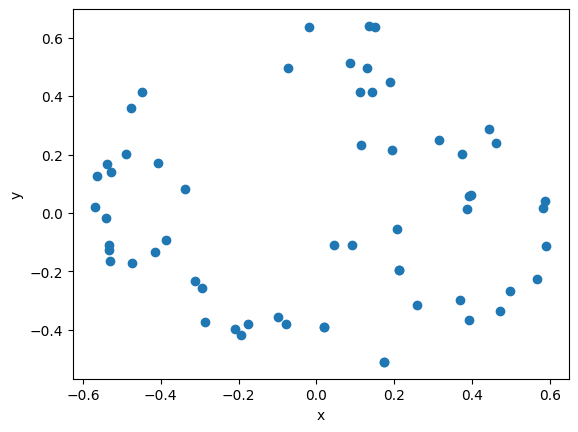

In [84]:
#可視化
x= X_kpca[:,0]
y= X_kpca[:,1]

#x軸とy軸にラベル付け
plt.xlabel("x")
plt.ylabel("y")

#散布図を作成
plt.scatter(x, y)
#plt.xlim([-1, 1])
#plt.ylim([-1, 1])


#散布図を表示
plt.show()